<a href="https://colab.research.google.com/github/tyh2312/YingHui_ADALL/blob/main/ADALL_Week2Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import userdata
from openai import OpenAI

In [ ]:
# load in the dataset from github
github_raw_url = 'https://raw.githubusercontent.com/tyh2312/YingHui_ADALL/refs/heads/main/laptop_prices_2024_sgd_TL.csv'

In [ ]:
# read in the dataset
try:
  df = pd.read_csv(github_raw_url)
  print("Successfully loaded data from GitHub!")
  display(df.sample(10))
except Exception as e:
  print(f"Error loading data from GitHub: {e}")
  print("Please ensure the URL is correct and the file format is compatible")

Successfully loaded data from GitHub!


,Brand,Model,CPU,GPU,RAM_GB,Storage_Type,Storage_GB,Touchscreen,Weight_kg,Screen_Size_inch,Discount_percent,Price_SGD,Brand_Discount,Member_Discount
891,Microsoft,Surface Laptop Studio,Intel i7-14800H,NVIDIA RTX 4060,16,SSD,1024,True,1.12,13.3,8.86,2287.65,10,160.14
470,Dell,Latitude 7420,Intel Core Ultra 7 15500H,Intel Arc A750M,8,SSD,512,True,2.37,15.6,2.77,2315.04,3,162.05
759,Lenovo,Legion 5,AMD Ryzen 5 8600H,AMD Radeon 680M,16,SSD,2048,False,3.03,17.3,0.42,1507.37,10,90.44
455,Dell,XPS 15,Intel i7-14800H,NVIDIA RTX 4060,16,SSD,512,False,2.91,18.4,7.43,1817.12,3,127.20
807,Lenovo,ThinkBook 14s,AMD Ryzen 9 8900HX,NVIDIA RTX 4070,32,SSD,1024,True,2.80,17.3,3.57,2568.53,10,154.11
313,Asus,ExpertBook B9,Intel i5-14600H,NVIDIA RTX 4050,64,SSD,2048,True,1.12,14.0,3.28,2067.47,7,124.05
404,Dell,XPS 15,AMD Ryzen 7 8800H,NVIDIA RTX 4060,64,SSD,512,False,1.31,13.3,7.28,2011.22,3,120.67
432,Dell,Alienware M15,AMD Ryzen 9 8900HX,NVIDIA RTX 4070,8,SSD,512,False,1.07,13.3,3.18,2500.94,3,175.07
569,HP,Omen 15,Intel i7-14800H,NVIDIA RTX 4080,128,SSD,256,True,1.22,14.0,5.04,3253.04,5,162.65
956,Microsoft,Surface Pro 8,Intel Core Ultra 7 15500H,NVIDIA RTX 4070,64,SSD,1024,False,3.31,17.3,11.48,2803.54,10,196.25


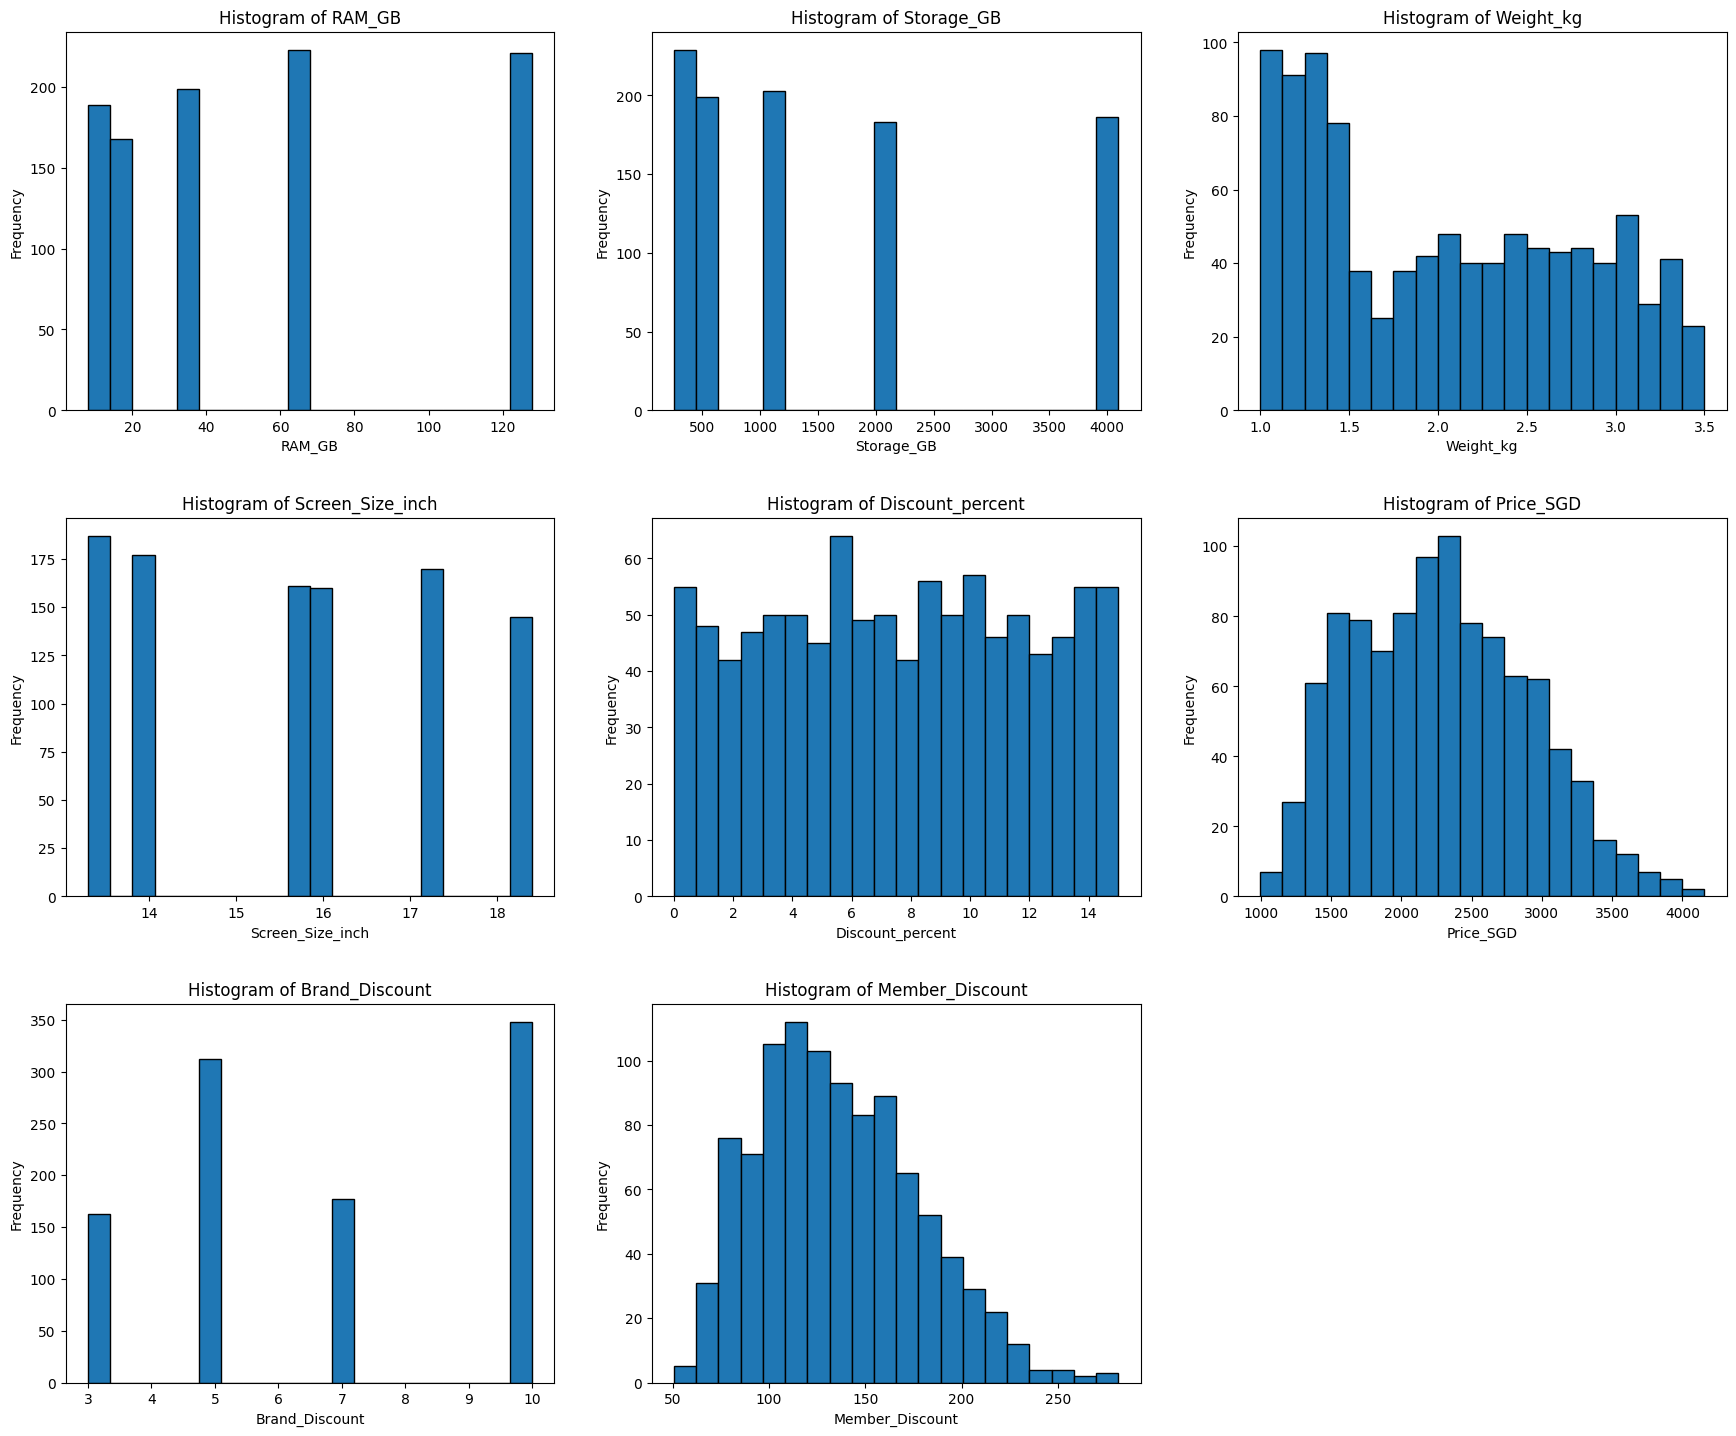

In [ ]:
numerical_columns = df.select_dtypes(include=['number']).columns
num_plots = len(numerical_columns)
num_cols = 3 # You can adjust this number
num_rows = (num_plots + num_cols - 1) // num_cols

# Increased figsize for better visual separation and clarity
fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 6, num_rows * 5))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, column in enumerate(numerical_columns):
  ax = axes[i]
  ax.hist(df[column], bins=20, edgecolor='black')
  ax.set_title(f'Histogram of {column}')
  ax.set_xlabel(column)
  ax.set_ylabel('Frequency')

# Hide any unused subplots
# This loop handles cases where num_plots is not a perfect multiple of num_cols
for j in range(i + 1, len(axes)):
  fig.delaxes(axes[j])

# Use tight_layout with padding to prevent labels/titles from overlapping
plt.tight_layout(pad=3.0)
plt.show()

In [ ]:
# Load key from Google Colab Secrets
api_key = userdata.get('OPENAI_API_KEY')

client = OpenAI(
    # This is the default and can be omitted
    api_key=api_key,
)
gpt_model = "gpt-5-mini"

